# Chapter 2: PyTorch, Datasets, and Models

## 2.2 Learning Objectives

By the end of this chapter, you should be able to:
- understand the difference between supervised and unsupervised learning
- understand the difference between software development and machine and deep learning
- understand the general idea behind building and training a model
- identify commonly used terms in machine and deep learning and their meanings

## 2.3 What is PyTorch?

PyTorch is an open source deep learning framework developed by Meta AI in 2016. It offers both modularity and flexibility, making it a capable tool for everything from tinkering with innovative models to maintaining an industry-scale application.

PyTorch can be used to solve many types of problems, but a good way to begin learning about PyTorch is to explore its ability to solve optimization problems. Let's say you'd like to estimate the fuel efficiency of cars based on their power and weight. You'll need data for this. PyTorch can help you develop a model that predicts the car's efficiency based on its power and weight. This would be a specific type of optimization problem called a linear regression model, and this model would be called a linear regression model. This is a simple problem that could be solved in Excel, but this makes it a useful thought experiment to begin wrapping your head around the sorts of problems PyTorch can solve.

But, what about really complex problems? What if you have lots and lots of features (like hundreds or thousands of columns in a spreadsheet)? What if you have a humongous amount of data (picture millions of rows in a spreadsheet)?

PyTorch uses an algorithm called gradient descent that is capable of looking for solutions regardless of how complex your problem is, or how massive the amount of data is. It starts from a random point and, little by little, works on improving the solution, one baby step at a time. This is performed by PyTorch's autograd module, which does the heavy lifting for you so you can focus on more interesting matters.



## 2.4 The PyTorch Ecosystem

The range of fields and applications that can be powered by PyTorch is extensive:
- Computer Vision (Kornia, Medical Open Network for Artificial Intelligence (MONAI), OpenMMLab, PyTorchVideo, Detectron2, PyTorch3D)
    - machine and vehicular object detection, tracking, identification, and avoidance
    - medical image analysis and diagnosis
    - image recognition, classification, and tagging
    - video classification and detection

- Natural Language Processing (AllenNLP, NeMo, Transformers, flair)
    - text classification, summarization, generation, and translation
    - virtual assistants
    - sentiment analysis
    - question answering and search engines

- Graph Neural Networks (torchdrug, PyTorch Geometric, DGL)
    - molecule fingerprinting
    - drug discovery and protein interface prediction
    - social network analysis

- Spatio-Temporal Graph Neural Networks (PyTorch Geometric Temporal)
    - route planning and navigation
    - traffic control and management
    - inventory planning
    - logistics optimization

- Gaussian Processes (GPyTorch)
    - time series modeling and anomaly detection
    - risk management
    - control engineering and robotics
- Reinforcement Learning (PRFL)
    - industry automation and robotics manipulation
    - dynamic treatment regimes (DTRs) in healthcare
    - real-time bidding
    - strategy games
- Recommender Systems (TorchRec)
- Interpretability and Explainability (Captum)
- Privacy-Preserving Machine Learning (CrypTen, PySyft, Opacus)
- Federated Learning - collaboratively training a model without the need to centralize the data (PySyft, Flower)

PyTorch has a very rich ecosystem of tools and libraries. From high-level libraries (e.g. PyTorch Lightning, fast.ai, Ignite, Catalyst, Skorch) that handle most of the boilerplate involved in developing and training models to highly-specialized ones (e.g. TorchDrug, ChemicalX) for drug discovery. There are supporting libraries to improve model interpretability (e.g. Captum) and ensure data privacy (e.g. PySyft) as well. In a nutshell, there are libraries and pre-trained models available for a wide range of topics and applications.

And then there’s HuggingFace, which is widely known for its large open-source community, its model hub, and its array of Python libraries, especially in the area of natural language processing (NLP), since it started as a chatbot company in 2016.

### Hugging Face

A discussion of the PyTorch ecosystem would not be complete without mentioning Hugging Face. While not a part of PyTorch, it is widely known for its large open-source community and is a central hub for models and Python libraries, especially in the area of natural language processing (NLP). Because it is so often used alongside PyTorch, it belongs in any discussion of the PyTorch ecosystem and we will make use of it in this course.

## 2.5 Supervised vs Unsupervised Learning

The majority of models and algorithms in machine and deep learning fall into one of these classes: supervised learning and unsupervised learning.

To train a model using supervised learning is like actively teaching a toddler. You can show them a picture of a zebra and ask them what they see. They reply "it's a horse", because they've never seen a zebra before. You tell them it was a good guess, but the right answer is "zebra". You're supervising their learning by providing the right answer to every question. Hopefully, with enough examples and their corresponding answers, your model will also learn. Sometimes, though, you'll have to accept that the model you're training isn't powerful enough to tell a Chihuahua from a muffin:

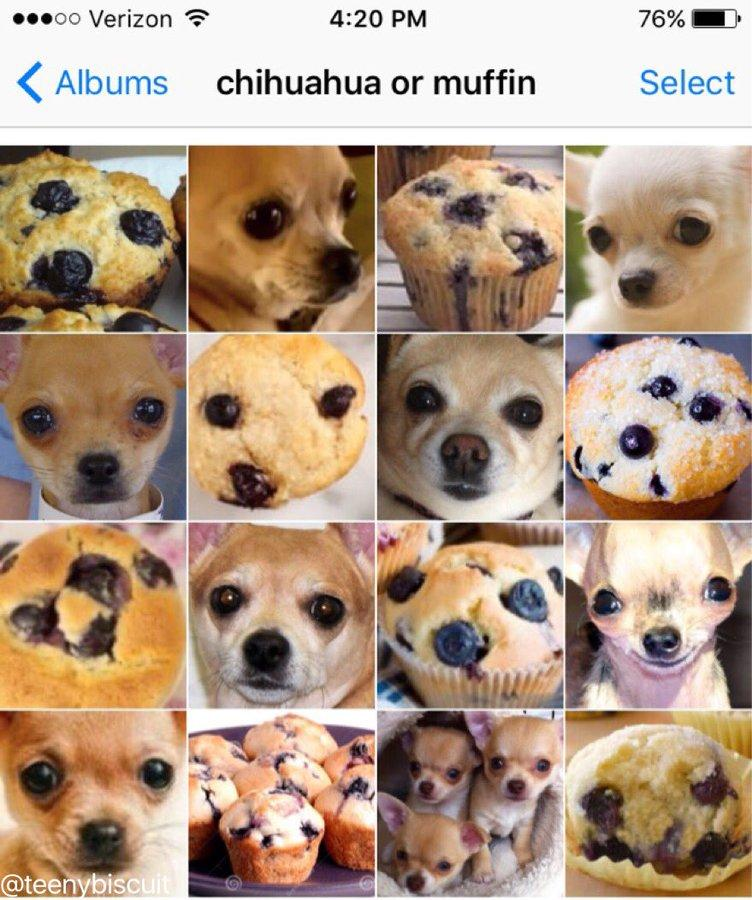https://d36ai2hkxl16us.cloudfront.net/course-uploads/e0df7fbf-a057-42af-8a1f-590912be5460/4zfnpam0v8eq-ChihuahuaorMuffin.jpeg

![](https://pbs.twimg.com/media/CdJavKoUAAAFLBG?format=jpg&name=900x900)
Source: [@teenybiscuit](https://twitter.com/teenybiscuit/status/707727863571582978/photo/1) on Twitter

Unsupervised learning, on the other hand, is like giving a toddler a bunch of building blocks and asking them to organize them without any specific instructions on how to do it. Maybe the toddler will split the blocks by color. Maybe they will split the blocks by size. It depends on which feature of the blocks, the color or the size, is more noticeable to them. Notice that you're not giving the toddler any "right" answers. It's exactly the same with these models and algorithms: they will look for similarities in the data, and use it to split it into groups. We won't be covering those in this course.

## 2.6 Software Development vs Machine and Deep Learning

### Software Development
What do you do when you have to write a function in Python? First, you think about the purpose of the function: converting temperature from Celsius to Fahrenheit, for example. Then, you probably think about which argument(s) your function needs, and what it should return. In our example, it takes one temperature (in Celsius) and returns another temperature (in Fahrenheit). There's a clear formula for that, you just have to look it up and implement it in code:
```python
def celsius2fahrenheit(celsius):
    fahrenheit = celsius*(9/5)+32
    return fahrenheit
```

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/sw10.png)

### Machine and Deep Learning
It's easy. If you know the rules, that is.

Things start to fall apart quickly if the rules aren't clear. Let's go back to our toddler and the zebra. If they're seeing the zebra for the first time, they may ask you: "is this a horse?" And you'll explain to them that it's not a horse, even though both animals have four legs. Zebras have stripes. That should do the trick for the toddler. But what about code? Can you write a function that takes an image and returns if it's a zebra or not?
```python
def contains_zebra(image):
    # write your code here
    is_zebra = ...    
    return is_zebra
```

How do you even start coding that?! We challenge you to try to come up with a set of rules to determine if an image shows a zebra in it or not. That's impossibly hard using traditional software development.

![](https://imgs.xkcd.com/comics/tasks.png)

Source: [XKCD](https://xkcd.com/1425)

Still, the toddler can easily learn that after a couple of tries. How? They're learning by example, not by rules. You show the toddler the picture of the zebra (the input), and you tell them the answer (the desired output). Their brain comes up with the rules, even if no one can write them down or implement them in a function.

That's "Software 2.0". You don't know the rules: you only have inputs and outputs. Unlike toddlers, however, it won't take just a couple of tries for a model to learn. It will need thousands, if not millions, of examples. That's just how models are.

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/sw20.png)

If the problem is simple enough, though, even a handful of examples may do the trick. Let's try a very simple model!

## 2.7 "Hello Model"
Let's train a simple model from scratch to give you a better idea of the process. It is the "Hello World" of training models or, better yet, the "Hello Model".
Four cars: ["Chevrolet Chevelle Malibu"](https://en.wikipedia.org/wiki/Chevrolet_Chevelle), ["Buick Skylark 320"](https://en.wikipedia.org/wiki/Buick_Skylark), ["AMC Rebel SST"](https://en.wikipedia.org/wiki/AMC_Rebel), ["Ford Torino"](https://en.wikipedia.org/wiki/Ford_Torino).

For each car, we know its power in HP: 130, 165, 150, and 140, respectively.

We also know that the more powerful a car is, the less efficient consumption-wise it will be too. But, how inefficient? It would be interesting to devise a rule to figure out, given the car's power, how efficient (or not) we expect it to be.

So, let's drive them around and collect some fuel consumption data! Once data is collected, we get the desired output of our model for the cars we drove around.
The fuel-consumption for each one of the cars, in miles per gallon, is 18, 15, 16, and 17, respectively.

We have data (power in HP), we have the desired output (fuel consumption in MPG), and we're missing the rule that maps one into the other. Sounds like a task for "Software 2.0", that is, a model.

What's the simplest model you can come up with?

How about a simple average? We simply average the desired output: 16.5 miles per gallon. Regardless of the power's car, the model always predicts 16.5. Not quite a model, of course. But it doesn't perform so badly for the cars we know, right? It's off the mark for 1.5 miles per gallon at most. It will fail badly, however, if we try estimating the fuel consumption of a 60 HP car.

We can do better; let's plot the data to check if our intuition holds:

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/hp_mpg.png)

###  Power vs Fuel Consumption

Sounds about right: the most powerful car is the one that makes fewer miles per gallon than all four cars. Notice that the four points are neatly lined up. Let's focus on the two outer points and do some back-of-the-envelope math here. Using these two points alone, we can estimate that, for an increase in power of 35 HP, the number of miles per gallon was reduced by three.

In other words, for every extra HP, fuel consumption gets worse by 0.0857 (three divided by 35) miles per gallon. Well, that's a better model already! In effect, it is as if we were drawing a line connecting the two outer points, as shown below:

Let's use the two extreme points only and build a formula out of them:

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/hp_model.png)

A Simple Model

We can write it as a formula:

$$
\Large
\text{MPG} = 18 - \frac{3}{35}(\text{HP} - 130) = 18 - 0.0857 (\text{HP} - 130)
$$

What if we wanted to use our new model to estimate the fuel consumption of the Ford Torino? It has 140 HP, which is 10 HP more than the Chevy Malibu (the left-most point). Therefore, our model estimates that Torino's fuel consumption will be 0.857 miles per gallon worse than Malibu's, which gives us 17.143 miles per gallon. The actual value for the Malibu is 17, so our model is pretty decent.

In the formula, it looks like this:

$$
\Large
\text{MPG} = 18 - \frac{3}{35}(140 - 130) = 18 - 0.0857 (10) = 17.143
$$

Of course, that's a very contrived example. What we did here is equivalent to fitting a linear regression using the two outer points only, and making predictions for one of the other points.

By the way, in the model above, we have:
- a feature, which is an attribute of the car, power (in HP)
- a target, the fuel-consumption of the car (in MPG)
- two parameters, 18 and -3/35
- the second parameter, -3/35, may also be called a weight since it's a multiplying factor for a feature (HP)
- the model's estimate for the Ford Torino, 17.143, is called a prediction
- the difference between the prediction (17.143) and the Torino's actual consumption (17) is called an error

As you can see, there's a lot of jargon involved. Let's talk a bit more about this.

## 2.8 Naming Is Hard
This is especially true in the field of Machine Learning and Deep Learning. While some concepts may have several names, some names are also used to represent different concepts. This may be particularly confusing for a beginner in the field, so we'll present you a short overview of the most common cases, so you know what a given term refers to.
### 2.8.1 Datasets

A dataset contains the data you'll use to train a model. In some cases, the elements are easy to identify: for computer vision problems, a dataset is made of images. Each individual image, however, may be referred to in a variety of ways:
Each dataset has a number of elements which may be called:

- a data point
- a sample
- an instance

One image, one data point, one sample, or one instance. Regardless of the name, it's easy to make an association between an image and its name. Moreover, even though images are made of thousands of pixels, we don't take their individual values as meaningful.

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/two_images.png)

Two Images as Two Data Points

#### Tabular Data

Tabular data, that is, spreadsheet-like data such as a table, is a completely different matter. In a table, a row usually represents a data point, and each individual value contained in every column is meaningful, and may be referred to in a variety of ways as well:

- an attribute
- a feature
- a dimension

The first two, feature and attribute, are used somewhat interchangeably. In most cases, an attribute represents a characteristic or property that's observed or measured (such as color, size, weight, etc.). The term feature may be used to represent these things, but its usage is generally broader, and it may refer to transformed attributes or completely abstract values such as intermediate values produced by models or algorithms. Therefore, you'll see features everywhere: feature extraction, feature transformation, feature engineering, and so on.

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/table_features.png)
#### A Table

The third term, dimension, is a different beast altogether. You can think of it as an even more generic term to refer to a value or a column. If a data point has ten values associated with it, such as ten columns in a table (where each data point is a row), it's possible to say the data point has 10 dimensions, with each column/attribute/feature representing a different dimension.

#### Dimension

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/features_dim.png)

Features as Dimensions

Dimension itself, however, is one of those terms that may represent different things:
- one attribute/feature/column
- the number of levels in a nested array

We already discussed the first meaning dimension has, so let's focus on the second. You can think of it almost as a "physical" dimension.

For example, a single row of values is like a horizontal line, and therefore it has only one dimension, from left to right. A single column of values is like a vertical line, and it also has only one dimension, from top to bottom.

A table containing many rows and columns is like a rectangle, and therefore it has two dimensions. An image also has two dimensions, height and width.

#### Two Dimensions

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/image_hw.png)

A Single-Channel Image

Now, imagine that each table is printed on a square sheet of paper, let's say, one table per day. If you stack many, many, sheets of paper, it will eventually look like a cube, and therefore it has three dimensions. Colored images are also three-dimensional, but not in a physical sense, obviously. Each image is internally represented by three channels, one for red, one for green, and another one for blue (thus RGB). These channels work like stacked sheets of paper, thus making colored images three-dimensional: channel, height, and width.

#### Three Dimensions

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/image_chw.png)

### An RGB Image

One single image may be a data point, as we've already discussed. What happens if we have many images, say, 32 of them, and we stack them up? We're in the realm of four dimensions now! Unfortunately, we cannot easily draw analogies from the physical world anymore, but we can represent the extra dimension as yet another nested level: image ID, channel, height, and width. Luckily, this is usually as far as we go when it comes to nesting arrays. It is quite unlikely that you'll ever see five or more levels when dealing with typical tasks.

#### Four Dimensions

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/image_nchw.png)

### A Batch of RGB Images

Features are used as inputs to a model but, as we've seen in the Software 2.0 paradigm, we also need to provide an "answer" or "result" so the model may try to learn the relationship between the features and this "answer" or "result". As you probably guessed, this one also goes by different names:

- a label
- a target

If the "answer" is a name, such as "dog", "cat", "red", or "down", it is usually called a label, even though it may also be referred to as the target. If the "answer" is numerical, it is more likely to be referred to as a target. The term target, however, may refer to a more complex answer, such as a combination of numerical values and names.

In tabular data, that is, when we're talking about tables or stacks of tables, the target or label is usually one of the columns from the table. This particular column should be used exclusively as a target or label, and excluded from the set of features.

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/features_target.png)

### Features and Target

In other types of data, such as images, the label ("dog", "cat", "raccoon") isn't part of the image, but part of its corresponding metadata or annotation. Someone needs to actually inspect the image, see what it represents, and label it accordingly, so the information is provided in the dataset the model will use to try to learn the relationship between the input images and their labels.

A set of pairs of features and their corresponding labels or targets is what we usually call a dataset in the context of supervised learning.

### 2.8.2 Models

Models may be as simple as linear regression or as complex as a Transformer such as GPT models. Regardless of their size, models are nothing more than a set of values, from a few values in linear regression to billions of values in GPT models.

These values, which are learned during the training process, also go by different names:

Values learned during training may be called:

- coefficients
- parameters
- weights

The first term, coefficient, is generally used in simple linear regression tasks only. For each feature, there is a corresponding coefficient, and multiplying them pairwise will yield a prediction. A coefficient is a parameter or weight of the model (linear regression).

In the figure below, each line connecting a feature to the target is a coefficient of linear regression. Or you can call it a parameter. Or a weight as well.

#### Linear Regression

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/lin_reg.png)
#####Linear Regression as a Neural Network

The other two terms, parameters and weights, are used interchangeably, and do not necessarily map to the input features. A relatively simple neural network may have many more parameters/weights than input features. However, at each stage of the network, referred to as a layer, many intermediate values are produced. These values, as we already discussed, are often referred to as features as well. And for each one of these intermediate features, there will be a corresponding parameter/weight.

In a way, you can think of a neural network as a "stack of linear regression models", the output of one regression being the input of the next. Of course, this is a very simplified picture, and it does not correspond to the reality of deep learning models, which include many other transformations in-between.

In the figure below, the original features are inputs to each one of the ten nodes in the center. It is as if we were computing ten independent linear regressions. The result of each one of these regressions is an intermediate feature for the linear regression at the end. Each line connecting any two nodes is a parameter or weight. You can see that adding an extra layer of regressions in the middle increased considerably the total number of parameters or weights. That's still a simplified version of an actual neural network, but it paints the general picture nonetheless.

#### Neural Network

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/neural_net.png)

In the end, the value that the model ultimately produces is called a prediction, and the goal is that it is as close as possible to the target or value associated with the input used by the model.

####Neural Network

## 2.9 Setup and Environment
Deep Learning models are computationally expensive and, although it's possible to run smaller models in the CPU of a regular computer, you'll save a lot of time (and energy) by leveraging the power of a GPU, a graphics card such as a GTX 1080 or an RTX 3080. However, these cards are expensive, and setting up their drivers to work with PyTorch may be a cumbersome and difficult process.

For this reason, we're prioritizing the usage of free cloud providers such as Google Colab, Kaggle Notebooks, or Amazon Sagemaker Studio. These platforms offer free GPUs that can be used to train, fine-tune, and run the models we'll be handling in this course. Moreover, their environments come up with all major libraries already preinstalled: PyTorch, Numpy, Scikit-Learn, Pandas, Matplotlib, etc.

This course was prepared to run in Google Colab, but it should run with little to no modification in any of the other platforms as well. Moreover, we'll tell you whenever there are any extra libraries that need to be installed on top of those already available (in Colab, that is).

### 2.9.1 Colab
Google Colab "allows you to write and execute Python in y|our browser, with zero configuration required, free access to GPUs and easy sharing." You can create Jupyter Notebooks in Google Colab from scratch, upload them from your computer, or load them directly from GitHub. Every notebook you create is automatically stored in your Google Drive, so any changes you make to the notebook are preserved.

For a quick overview of Google Colab's capabilities, check the "Welcome To Colaboratory" and "Overview of Colaboratory Features" notebooks.

One important thing to notice: in order to use a free GPU, you'll need to change the runtime type before running any code, otherwise you'll have to re-run everything. You can easily change it in the "Runtime" menu, "Change runtime type" entry, as shown below:
#### Setting Up The Device / GPU

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/colab_runtime.png)

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/runtime.png)

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/runtime2.png)

## 2.10 Your Learning Journey

The course is divided into four main parts, as shown below:

- Part I: Training a Model in PyTorch (three chapters)
  - Building Your First Dataset
    - Lab 1A: Non-Linear Regression
  - Training Your First Model
    - Lab 1B: Non-Linear Regression
  - Building Your First Datapipe
    - Lab 2: Price Prediction
- Part II: Transfer Learning (three chapters)
    - Transfer Learning and Pretrained Models
        - Lab 3: Classifying Images
    - Pretrained Models for Computer Vision
    - Pretrained Models for Natural Language Processing
        - Lab 4: Sentiment Analysis
- Part III: Computer Vision (six chapters)
    - Image Classification with Torchvision
    - Fine-Tuning Pretrained Models for Computer Vision
    - Serving Models with TorchServe
    - Datasets and Transformations for Object Detection and Image Segmentation
        - Lab 5A: Fine-Tuning Object Detection Models
    - Models for Object Detection and Image Segmentation
        - Lab 5B: Fine-Tuning Object Detection Models
    - Object Detection Evaluation
- Part IV: Natural Language Processing (four chapters)
    - Word Embeddings and Text Classification
        - Lab 6: Text Classification Using Embeddings
    - Contextual Word Embeddings with Transformers
    - HuggingFace Pipelines for NLP Tasks
        - Lab 7: Document Q&A
    - Q&A, Summarization, and LLMs

![](https://raw.githubusercontent.com/dvgodoy/assets/main/PyTorchInPractice/images/ch0/data_model_step0.png)